## Environment Setup

### Directory

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
import skrom.problem_classes.static.master_class as master
from skrom.utils.visualization.generate_vtk import generate_vtk
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

## Full Order Simulation

In [3]:
generate = False

if generate:
    sim = master.fom_simulation()
    sim.run_simulation()

### Load Simulation data

In [4]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\computational_mechanics\static\linear\problem_1\ROM_data


## Data Generation

### Generate Training Solution Dataset

In [5]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Mean Subtraction

In [6]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Vizualize Parameters

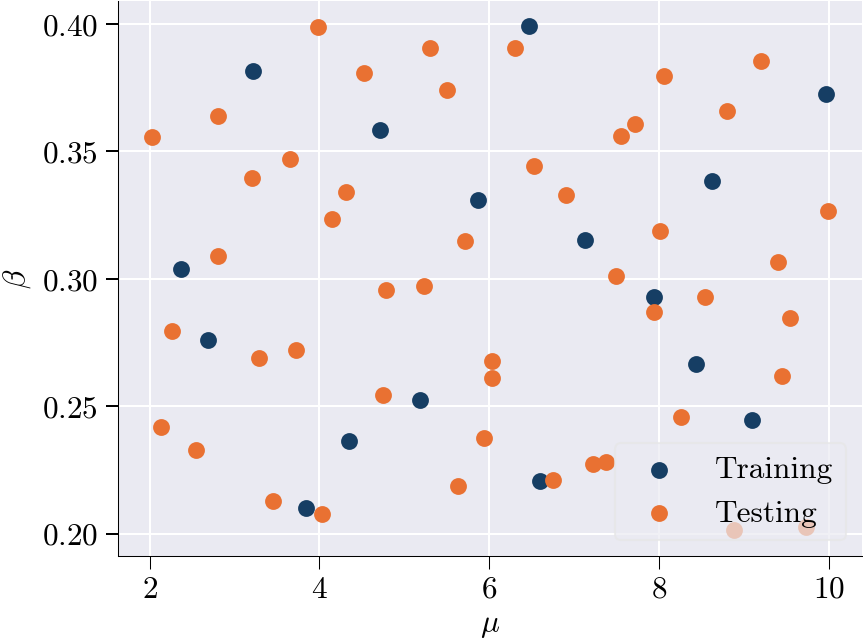

In [7]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on solution snapshots

Number of modes selected: 4


Text(0.5, 0, 'POD modes ($k$)')

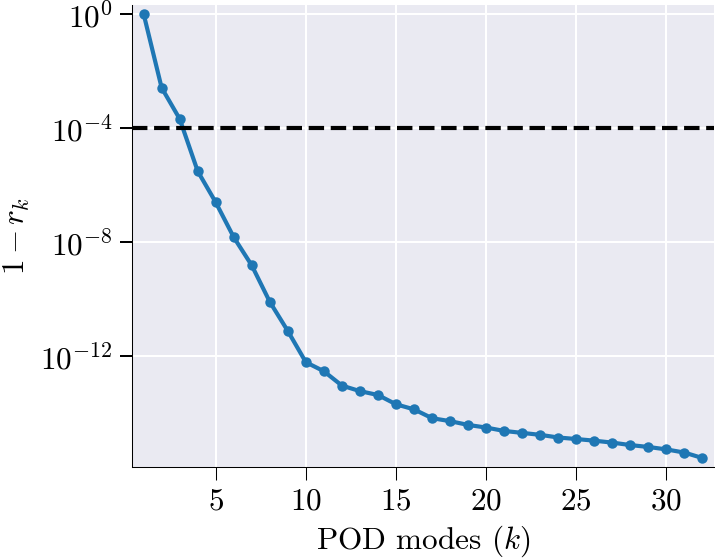

In [8]:
# fig, ax = plt.subplots(figsize=(5,3.5))
plt.rcParams['lines.markersize'] = 6
plt.rcParams['lines.linewidth'] = 2.0

n_sel, U = svd_mode_selector(LS_train_ms, tolerance = 1e-4, modes=True)
V_sel = U[:, :n_sel]
plt.ylabel('$1-r_{k}$')
plt.xlabel('POD modes ($k$)')

## ROM Simulation

In [9]:
#Run ROM simulation here:

rom = master.rom_simulation(V_sel = V_sel)

[load_rom_data] loaded from d:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\computational_mechanics\static\linear\problem_1\ROM_data


In [10]:
rom.run_rom_simulation();

Snap 1/64 params=[8.80179478 0.36593142]
Snap 2/64 params=[5.22627557 0.29715651]
Snap 3/64 params=[3.20849621 0.33973745]
Snap 4/64 params=[6.75707033 0.22101284]
Snap 5/64 params=[7.49346183 0.30118252]
Snap 6/64 params=[2.54292092 0.23260244]
Snap 7/64 params=[4.5251759 0.3806465]
Snap 8/64 params=[9.44871067 0.2617261 ]
Snap 9/64 params=[9.99075099 0.32648103]
Snap 10/64 params=[4.0353778  0.20770602]
Snap 11/64 params=[2.02154095 0.35574968]
Snap 12/64 params=[7.94209166 0.28702498]
Snap 13/64 params=[6.3073762  0.39063216]
Snap 14/64 params=[3.72704187 0.27205217]
Snap 15/64 params=[5.71317068 0.31463351]
Snap 16/64 params=[8.25874357 0.24571321]
Snap 17/64 params=[8.01660161 0.31877955]
Snap 18/64 params=[5.94115248 0.2376525 ]
Snap 19/64 params=[3.98587696 0.39897744]
Snap 20/64 params=[6.03438096 0.26760477]
Snap 21/64 params=[7.71609398 0.3608848 ]
Snap 22/64 params=[2.26560503 0.27956216]
Snap 23/64 params=[4.31035621 0.33386222]
Snap 24/64 params=[9.73383899 0.20268458]
Sna

In [11]:
#Assign values for the statistics
LS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up[1:]
ROM_relative_error = rom.rom_error

### ROM Solution vs Full order statistics

ROM Accuracy Report

Global Errors:
L2 Error:                 6.2307e-06
Relative L2 Error:        9.1284e-07
L∞ Error:                 3.6634e-06
Relative L∞ Error:        1.3020e-06
RMSE:                     2.5123e-07
MAE:                      7.8979e-08

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             -6.7735e-17
95th Percentile Error:    4.5012e-07

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.3020e-08
Max Rel L2 Error over time/parameter: 1.0168e-07
Min Rel L2 Error over time/parameter: 3.2348e-10
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

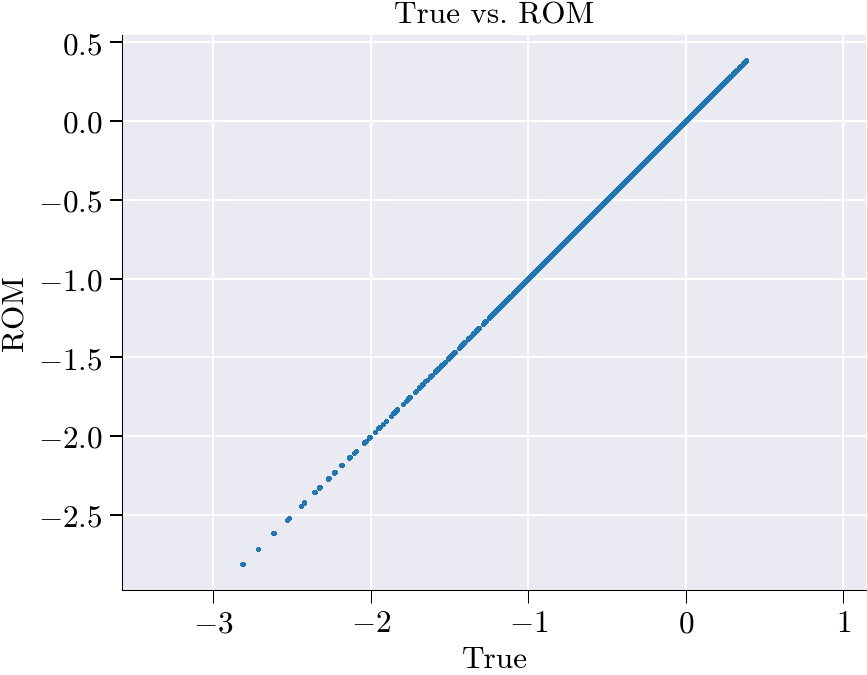

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


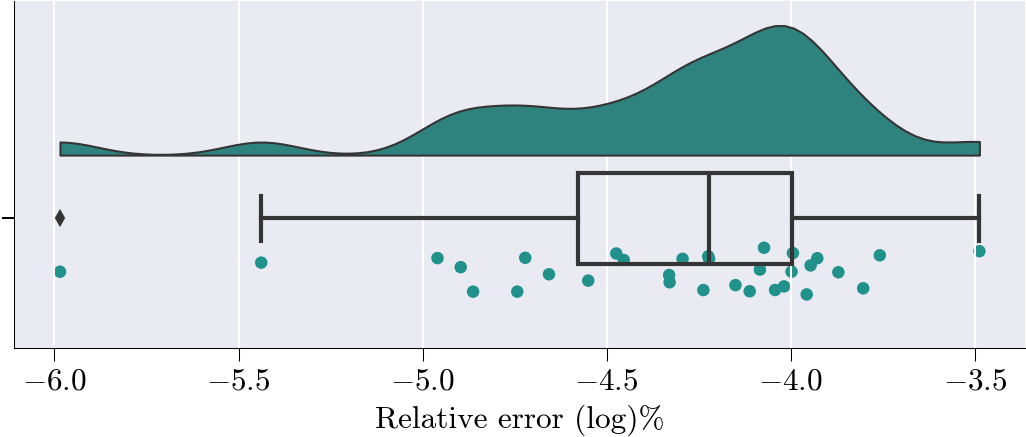

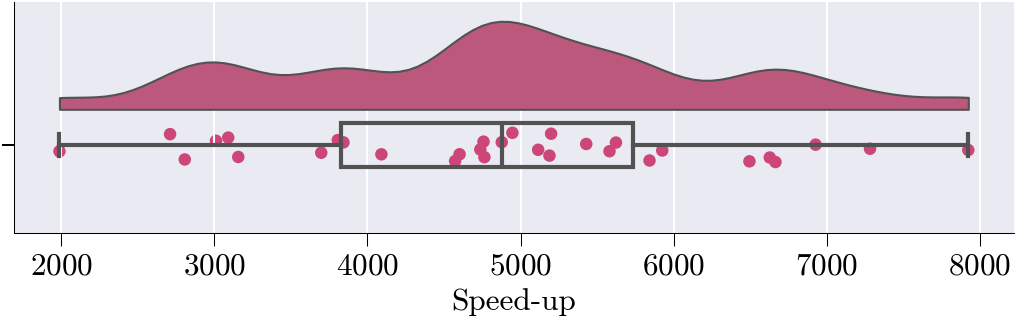

In [12]:
# --- ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    LS_test,                   # full-order (true) solution snapshots
    LS_rom,              # hyper-ROM-generated solution snapshots
    ROM_relative_error,   # precomputed relative error of the hyper-ROM
    ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

## Visualize on paraview 

In [13]:
generate_vtk(
    LS_test,
    LS_rom,
    sim_data['mesh'].item(),
    sim_data['basis'].item(),
    scale = 1.0,
    num_test = 1,
    out_dir = "sol_vtk_files",
)